In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [18]:
dataset = np.loadtxt('dataset.txt')


In [19]:

def normalize(X):
    X_minimum = X.min(axis=0)
    X_maximum = X.max(axis=0)
   
    return (X - X_minimum) / (X_maximum - X_minimum + 1e-8)

norm_data = normalize(dataset)



In [21]:
def euclidean_distance(point1, point2):

    distance = 0.0
    for v1, v2 in zip(point1, point2):
        distance += (v1 - v2) ** 2
    return math.sqrt(distance)



In [27]:

def compute_inertia(clusters, centers):

    inertia = 0.0
    for k in range(len(centers)):
        for pt in clusters[k]:
            inertia += euclidean_distance(pt, centers[k]) ** 2
    return inertia


In [28]:
def kmeans(data_points, number_of_clusters, seed=11320065, max_iterations=6):

    np.random.seed(seed)

    selected_indices = np.random.choice(
        len(data_points),
        number_of_clusters,
        replace=False
    )

    cluster_centers = [
        data_points[index].tolist()
        for index in selected_indices
    ]

    for iteration in range(max_iterations):

    
        clusters = [[] for _ in range(number_of_clusters)]

        for data_point in data_points:

            point = data_point.tolist()

            distances = [
                euclidean_distance(point, center)
                for center in cluster_centers
            ]

            nearest_cluster_index = distances.index(min(distances))

            clusters[nearest_cluster_index].append(point)

      
        updated_cluster_centers = []

        for cluster_index in range(number_of_clusters):

            if len(clusters[cluster_index]) == 0:

                updated_cluster_centers.append(
                    cluster_centers[cluster_index]
                )

            else:

                number_of_points = len(clusters[cluster_index])

                center_x_coordinate = 0.0
                center_y_coordinate = 0.0

                for point in clusters[cluster_index]:

                    center_x_coordinate += point[0]
                    center_y_coordinate += point[1]

                updated_cluster_centers.append([
                    center_x_coordinate / number_of_points,
                    center_y_coordinate / number_of_points
                ])

        
        total_center_shift = sum(
            euclidean_distance(
                cluster_centers[cluster_index],
                updated_cluster_centers[cluster_index]
            )
            for cluster_index in range(number_of_clusters)
        )

        cluster_centers = updated_cluster_centers

        if total_center_shift < 1e-6:

            print(
                f'[K={number_of_clusters}] converged at iteration {iteration + 1}'
            )

            break

    return cluster_centers, clusters

In [32]:
k_values = [2, 4, 6, 7]
results  = {}

print(f"{'K':>4}  {'Inertia':>14}  {'Cluster Sizes'}")
print("-" * 100)

for K in k_values:
    centers, clusters = kmeans(norm_data, K)
    inertia = compute_inertia(clusters, centers)
    results[K] = {'centers': centers, 'clusters': clusters, 'inertia': inertia}
    sizes = [len(clusters[k]) for k in range(K)]
    print(f"{K:>4}  {inertia:>14.5f}  {sizes}")

   K         Inertia  Cluster Sizes
----------------------------------------------------------------------------------------------------
   2        20.57393  [139, 234]
   4        10.46239  [94, 109, 28, 142]
   6         4.74145  [56, 54, 26, 69, 94, 74]
   7         4.16687  [54, 29, 26, 69, 83, 45, 67]


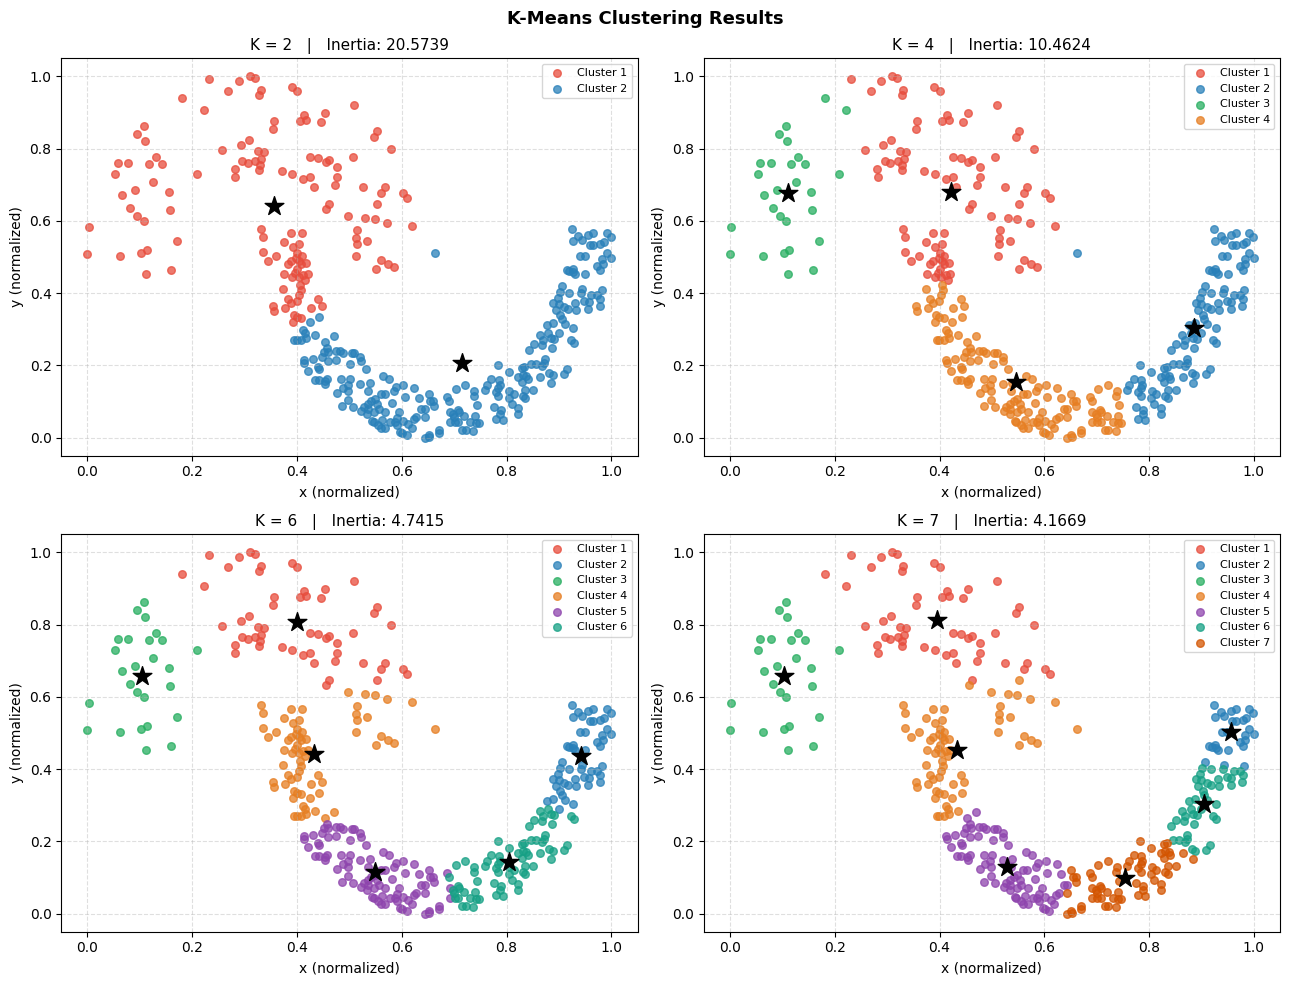

In [33]:
clr = ['#e74c3c', '#2980b9', '#27ae60', '#e67e22',
       '#8e44ad', '#16a085', '#d35400']

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
flat_ax = axes.ravel()

for i, K in enumerate(k_values):
    ax = flat_ax[i]
    cls = results[K]['clusters']
    cnt = results[K]['centers']

    for k in range(K):
        if len(cls[k]) > 0:
            pts = np.array(cls[k])
            ax.scatter(pts[:, 0], pts[:, 1], c=clr[k], s=30,
                       alpha=0.75, label=f'Cluster {k+1}')

    # plot centers as black stars
    for c in cnt:
        ax.scatter(c[0], c[1], c='black', marker='*', s=200, zorder=6)

    ax.set_title(f'K = {K}   |   Inertia: {results[K]["inertia"]:.4f}', fontsize=11)
    ax.set_xlabel('x (normalized)')
    ax.set_ylabel('y (normalized)')
    ax.legend(fontsize=8, loc='best')
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('K-Means Clustering Results',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('kmeans_clusters.png', dpi=150)
plt.show()

   K         Inertia
----------------------
   2       20.573931
   4       10.462394
   6        4.741451
   7        4.166866


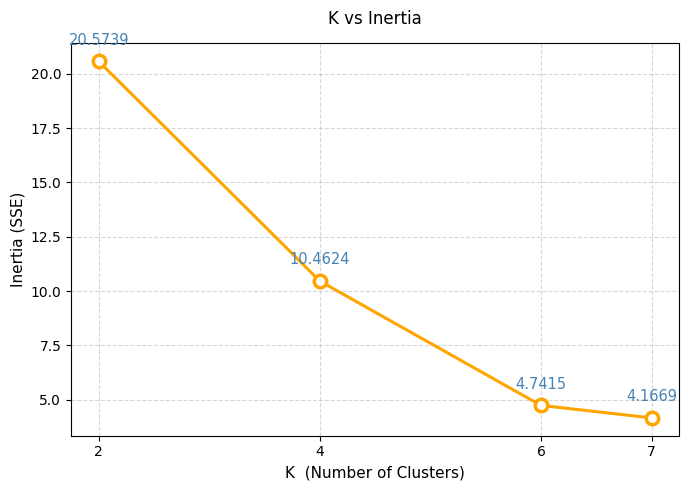

In [36]:
print(f"{'K':>4}  {'Inertia':>14}")
print("-" * 22)
for K in k_values:
    print(f"{K:>4}  {results[K]['inertia']:>14.6f}")

inertia_vals = [results[K]['inertia'] for K in k_values]

plt.figure(figsize=(7, 5))

plt.plot(k_values, inertia_vals, marker='o', color='orange',
         linewidth=2.2, markersize=9, markerfacecolor='white',
         markeredgewidth=2.5)

for K, val in zip(k_values, inertia_vals):
    plt.annotate(f'{val:.4f}',
                 xy=(K, val),
                 xytext=(0, 12),
                 textcoords='offset points',
                 ha='center',
                 fontsize=10.5,
                 color='steelblue')

plt.title('K vs Inertia', fontsize=12, pad=14)
plt.xlabel('K  (Number of Clusters)', fontsize=11)
plt.ylabel('Inertia (SSE)', fontsize=11)
plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('kmeans_elbow.png', dpi=150)
plt.show()
